# Moments Cross-Check: sft-wick vs sachsfield MC

We validate the perturbative moment computation (Feynman diagrams via sft-wick) against direct simulation (ODE evolution).

**Observable:** $\mu_n = \left\langle \left[\int_0^{\lambda_f} \xi_1(\lambda)\,d\lambda \right]^n \right\rangle$

**Toy model:**
Fluctuations ($\delta s$): source correlation $C_\ell^{ij}(\lambda', \lambda'') = \delta_{ij}\,\frac{A}{\ell(\ell+1)}\, e^{- c\,(\lambda'-\lambda'')^2}$ with $A=10^{-15}$, $c = 0.01$ for $\ell>0$.

Background (monopole): constant $\bar{s}_1=-10^{-6}$, $\bar{s}_2 = \bar{s}_3 = 0$.

**Range:** Affine parameter $\lambda$ from $0$ to $2000$.

**Response propagator:**
$$R_{ab}(\lambda, \lambda') = R(\lambda, \lambda') \delta_{ab}, \qquad R(\lambda, \lambda') = \Theta(\lambda - \lambda') \exp\!\left( - \bar{\chi}(\lambda, \lambda') \right)$$
where $\bar{\chi}(\lambda, \lambda') = \int_{\lambda'}^\lambda \chi_1^{(\mathrm{sa})}(\tau)\,d\tau$.

**Correlation propagator:**
$$C_{ab}(\lambda_1, \lambda_2) = \int_0^{\lambda_1} d\lambda' \int_0^{\lambda_2} d\lambda''\, \kappa^{(2)}_{ab}(\lambda', \lambda'')\, R(\lambda_1, \lambda') \, R(\lambda_2, \lambda'')$$

Both propagators are tabulated on a grid and treated as linear algebra operations.

**Environment:** `conda run -n sft-wick` (sft_wick + sachsfield + healpy).

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys, os
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.integrate import cumulative_trapezoid
import healpy as hp

# sachsfield (add parent to path)
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import sachsfield as sf
from sachsfield.saddle import solve_singular_theta
from sachsfield.fluctuations import FluctuationSolver

# sft-wick
from sft_wick import (
    Field, Vertex, Action, compute_moment, reset_uid_counter,
    PropagatorModel, PropagatorCache, integrate_moment, integrate_diagrams,
)

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

## 1. Parameters

In [20]:
# --- Physical parameters ---
A = 1e-15              # source amplitude
sbar_1 = -1e-6         # constant background for field 1
c = 0.01               # Gaussian correlation: exp(-c*(lam'-lam'')^2), corr length ~10
lam_f = 3000.0         # integration endpoint
epsilon = 1e-8         # epsilon for solve_singular_theta (saddle only)
lam_start = 1.0        # MC/fluctuation start — theta(1)~2, max_step~1.0 stable

# Full-sky grid
nside = 32
lmax = 3 * nside - 1   # = 95
npix = hp.nside2npix(nside)  # = 12288

# --- F tensor ---
F_physical = np.zeros((3, 3, 3))
F_physical[0, 0, 0] = -0.5
F_physical[0, 1, 1] = -2.0
F_physical[0, 2, 2] = -2.0
F_physical[1, 0, 1] = -1.0
F_physical[2, 0, 2] = -1.0
F_code = -1j * F_physical   # MSR convention

# --- Noise kernel amplitude ---
# S0 = A * sum_{ell=1}^{lmax} (2*ell+1) / (4*pi * ell*(ell+1))
ells = np.arange(1, lmax + 1)
ell_sum = np.sum((2 * ells + 1) / (4 * np.pi * ells * (ells + 1)))
S0 = A * ell_sum

# --- sft-wick field setup ---
phi = Field('phi', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)
v = Vertex(fields=[psi, phi, phi], coupling='F')
action = Action(vertices=[v])

print(f'A = {A:.2e}, sbar_1 = {sbar_1:.2e}, c = {c}')
print(f'lam_f = {lam_f}, lam_start = {lam_start}')
print(f'nside = {nside}, lmax = {lmax}, npix = {npix}')
print(f'ell_sum = {ell_sum:.6f}, S0 = {S0:.6e}')

A = 1.00e-15, sbar_1 = -1.00e-06, c = 0.01
lam_f = 3000.0, lam_start = 1.0
nside = 32, lmax = 95, npix = 12288
ell_sum = 0.738726, S0 = 7.387264e-16


## 2. Saddle Point and Response Propagator

Solve $d\theta/dt = -\tfrac12 \theta^2 + \bar{s}_1$ with $\theta \sim 2/t$ as $t\to 0^+$ using the stable $u$-substitution method (`solve_singular_theta`).

Then $\Phi(t) = \int_0^t \theta(\tau)\,d\tau$ and $R(t, t') = \exp\!\bigl(\Phi(t') - \Phi(t)\bigr)$ for $t > t'$.

Saddle solved: 6000 points in [1.00e-08, 3000.0]
theta(eps) = 200000000.0000,  2/eps = 200000000.0000
theta(lam_f) = -0.00086808
Phi correction: offset = -50008300.4 (trapezoid overestimate of 1/t integral)
Phi(t_trans=5.0) = 40.0602 (analytic: 40.0602)
Phi(lam_f) = 51.0316
Phi(lam_start→lam_f) = 14.2470


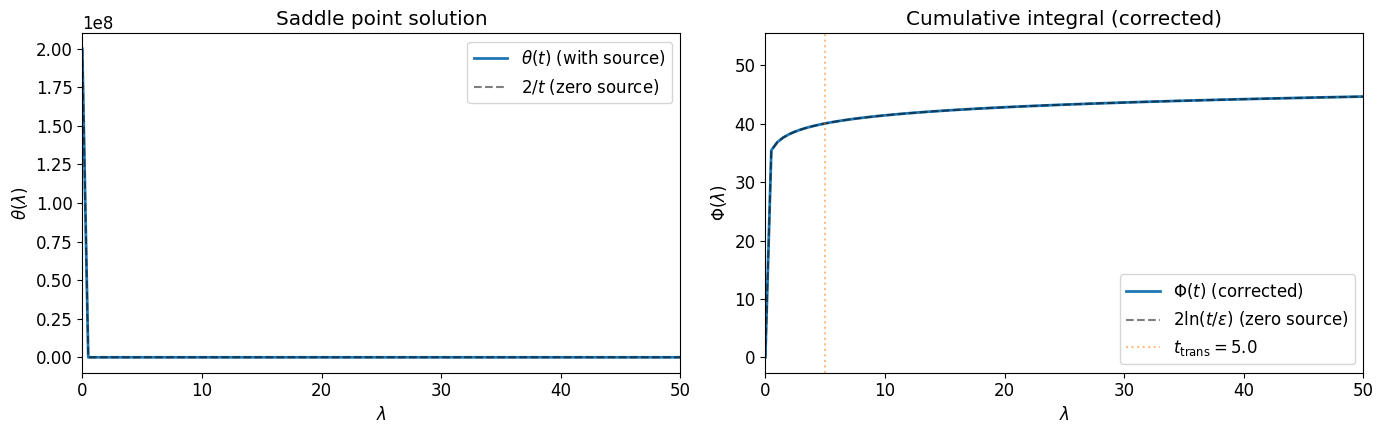


R(10, 5) = 2.496913e-01
R(100, 50) = 2.503096e-01
R(1000, 500) = 2.840514e-01
R(10, 0.001) = 1.141271e-18  (t' < epsilon → 0)
R(5, 2) = 1.600727e-01  (near t_trans, should be finite)


In [21]:
# --- Solve saddle point ---
t_theta, theta_vals = solve_singular_theta(
    s=lambda t: sbar_1,
    t_max=lam_f,
    epsilon=epsilon,
    num_points=6000,
    method='Radau',
)
print(f'Saddle solved: {len(t_theta)} points in [{t_theta[0]:.2e}, {t_theta[-1]:.1f}]')
print(f'theta(eps) = {theta_vals[0]:.4f},  2/eps = {2/epsilon:.4f}')
print(f'theta(lam_f) = {theta_vals[-1]:.8f}')

# --- Build corrected Phi interpolator ---
# The uniform grid from solve_singular_theta (spacing ~0.4) cannot resolve
# the 1/t singularity: cumulative_trapezoid gives ~4e5 for the first interval
# where the true integral is ~26. This corrupts the cubic spline of Phi,
# causing R_time to overflow when sft-wick samples t values near 0.
#
# Fix: use analytic asymptotic Phi(t) = 2*ln(t/epsilon) for t < t_trans
# (valid since |sbar_1| * t_trans^2 << 1), then match to numerical Phi.
t_trans = 5.0  # transition point; sbar_1 correction < 1e-5 here

Phi_raw = cumulative_trapezoid(theta_vals, t_theta, initial=0.0)

# Analytic asymptotic at transition
Phi_analytic_at_trans = 2.0 * np.log(t_trans / epsilon)
# Numerical value at transition (has constant offset from bad first interval)
k_trans = np.searchsorted(t_theta, t_trans)
Phi_numerical_at_trans = Phi_raw[k_trans]
# Offset to align numerical to analytic
Phi_offset = Phi_analytic_at_trans - Phi_numerical_at_trans

# Build corrected Phi: analytic for t < t_trans, shifted numerical for t >= t_trans
Phi_corrected = Phi_raw + Phi_offset
Phi_corrected[:k_trans] = 2.0 * np.log(t_theta[:k_trans] / epsilon)

print(f'Phi correction: offset = {Phi_offset:.1f} (trapezoid overestimate of 1/t integral)')
print(f'Phi(t_trans={t_trans}) = {Phi_corrected[k_trans]:.4f} (analytic: {Phi_analytic_at_trans:.4f})')
print(f'Phi(lam_f) = {Phi_corrected[-1]:.4f}')

Phi_interp = interp1d(t_theta, Phi_corrected, kind='cubic', fill_value='extrapolate')

# Phi from lam_start (for MC quadrature — avoids the singular region entirely)
t_mc, theta_mc = solve_singular_theta(
    s=lambda t: sbar_1,
    t_max=lam_f,
    epsilon=lam_start,
    num_points=5000,
    method='Radau',
)
Phi_mc_raw = cumulative_trapezoid(theta_mc, t_mc, initial=0.0)
Phi_mc_interp = interp1d(t_mc, Phi_mc_raw, kind='cubic', fill_value='extrapolate')
print(f'Phi(lam_start→lam_f) = {Phi_mc_raw[-1]:.4f}')

# --- Response propagator ---
def R_time(t, t_prime):
    """R(t, t') = exp(Phi(t') - Phi(t)) for t > t' > 0, else 0."""
    if t <= 0 or t_prime <= 0 or t <= t_prime:
        return 0.0
    if t < epsilon or t_prime < epsilon:
        return 0.0
    diff = float(Phi_interp(t_prime) - Phi_interp(t))
    if diff < -500:  # underflow guard
        return 0.0
    return float(np.exp(diff))

# --- ThetaSaddleResult wrapper for FluctuationSolver ---
class ThetaSaddleResult:
    """Wrap solve_singular_theta output for FluctuationSolver compatibility."""
    def __init__(self, t, theta, n_fields=3):
        self.lam = t
        self.n_fields = n_fields
        self._theta_interp = interp1d(t, theta, kind='cubic', fill_value='extrapolate')

    def __call__(self, lam):
        lam_arr = np.asarray(lam, dtype=float)
        scalar = lam_arr.ndim == 0
        lam_arr = np.atleast_1d(lam_arr)
        chi = np.zeros((self.n_fields, len(lam_arr)))
        chi[0] = self._theta_interp(lam_arr)
        return chi[:, 0] if scalar else chi

    def M(self, lam):
        theta_val = float(self._theta_interp(lam))
        return np.diag([-theta_val] * self.n_fields)

# Use t_mc grid (starts at lam_start=1) — well-behaved interpolation.
# t_theta grid starts at epsilon=1e-6 where theta~2e6, causing wild cubic
# interpolation that crashes FluctuationSolver's adaptive stepper.
theta_saddle = ThetaSaddleResult(t_mc, theta_mc)

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.plot(t_theta, theta_vals, 'C0-', lw=2, label=r'$\theta(t)$ (with source)')
ax.plot(t_theta, 2.0 / t_theta, 'k--', lw=1.5, alpha=0.5, label=r'$2/t$ (zero source)')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\theta(\lambda)$')
ax.set_title('Saddle point solution')
ax.set_xlim(0, min(50, lam_f))
ax.legend()

ax = axes[1]
ax.plot(t_theta, Phi_corrected, 'C0-', lw=2, label=r'$\Phi(t)$ (corrected)')
ax.plot(t_theta, 2.0 * np.log(t_theta / epsilon), 'k--', lw=1.5, alpha=0.5,
        label=r'$2\ln(t/\epsilon)$ (zero source)')
ax.axvline(t_trans, color='C1', ls=':', alpha=0.5, label=f'$t_\\mathrm{{trans}}={t_trans}$')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\Phi(\lambda)$')
ax.set_title('Cumulative integral (corrected)')
ax.set_xlim(0, min(50, lam_f))
ax.legend()

plt.tight_layout()
plt.show()

# Verify R propagator
print(f'\nR(10, 5) = {R_time(10.0, 5.0):.6e}')
print(f'R(100, 50) = {R_time(100.0, 50.0):.6e}')
print(f'R(1000, 500) = {R_time(1000.0, 500.0):.6e}')
print(f'R(10, 0.001) = {R_time(10.0, 0.001):.6e}  (t\' < epsilon → 0)')
print(f'R(5, 2) = {R_time(5.0, 2.0):.6e}  (near t_trans, should be finite)')

## 3. C Propagator Table

Compute $C_{aa}(t_1, t_2) = S_0 \cdot \mathbf{V}(t_1)\,\mathbf{G}\,\mathbf{V}(t_2)^T$ via matrix multiplication on a shared quadrature grid, then inject the spline table into `PropagatorCache`.

In [22]:
# === Step 1: Build C table via efficient matrix method ===
t0_build = time.time()

M_quad = 1000
q = np.linspace(epsilon, lam_f, M_quad)
dq = q[1] - q[0]
Phi_q = Phi_interp(q)

# Gaussian kernel with correlation parameter c
G = np.exp(-c * np.subtract.outer(q, q)**2)  # (M, M)

# Output grid for C table
N_out = 400
ts = np.linspace(epsilon, lam_f, N_out)
Phi_ts = Phi_interp(ts)

# Weight matrix: V[k, m] = exp(Phi(q_m) - Phi(ts_k)) * dq  if q_m <= ts_k
mask_v = q[None, :] <= ts[:, None]  # (N, M)
exponent = np.where(mask_v, Phi_q[None, :] - Phi_ts[:, None], -1e3)
V = np.exp(exponent) * dq  # (N, M)
V[~mask_v] = 0.0

C_table = S0 * (V @ G @ V.T)  # (N, N)

print(f'C table computed: {N_out}x{N_out} in {time.time()-t0_build:.1f}s')
print(f'C(lam_f, lam_f) = {C_table[-1, -1]:.6e}')
print(f'C(lam_f/2, lam_f/2) = {C_table[N_out//2, N_out//2]:.6e}')
print(f'Symmetric: max|C - C.T| = {np.max(np.abs(C_table - C_table.T)):.2e}')

# === Step 2: Build spline and inject into PropagatorCache ===
C_spline = RectBivariateSpline(ts, ts, C_table)

def kappa2(n1, t1, n2, t2):
    """kappa2 = S0 * exp(-c*(t1-t2)^2) * I_3."""
    return S0 * np.exp(-c * (t1 - t2)**2) * np.eye(3)

model = PropagatorModel(
    R_time=R_time, kappa2=kappa2,
    n_components=3, iso_R=True, diag_C=True, t_min=0.0,
)
cache = PropagatorCache(model)

# Inject pre-computed C splines (avoids expensive dblquad per grid point)
cache._c_splines = [C_spline] * 3
cache._c_table_range = (0.0, lam_f)

print(f'\nPropagatorCache ready with {N_out}x{N_out} C table')

# Spot-check
print(f'C(500,500) = {float(C_spline.ev(500,500)):.6e}')
print(f'C(1000,200) = {float(C_spline.ev(1000,200)):.6e}')
print(f'R(100,50) = {R_time(100.0,50.0):.6e}')

C table computed: 400x400 in 0.0s
C(lam_f, lam_f) = 3.661430e-11
C(lam_f/2, lam_f/2) = 4.980014e-12
Symmetric: max|C - C.T| = 3.88e-26

PropagatorCache ready with 400x400 C table
C(500,500) = 1.312193e-12
C(1000,200) = 2.489866e-14
R(100,50) = 2.503096e-01


## 4. sft-wick Diagram Computation

Compute moments $\mu_0$ through $\mu_4$ via Feynman diagrams at perturbative order 2 (tree + 1-loop + 2-loop).

In [23]:
# --- Compute moments mu_0 through mu_5 ---
n_max = 5
perturbative_order = 3

# Adaptive QMC samples: high orders are tiny corrections, need fewer samples
n_samples_by_order = {0: 2**16, 1: 2**16, 2: 2**14, 3: 2**12}

moments_wick = np.zeros(n_max + 1)
breakdown_wick = {}

# mu_0 = 1 by MSR normalization (vacuum bubbles cancel; sft-wick returns 0 diagrams)
moments_wick[0] = 1.0
breakdown_wick[0] = {0: 1.0}

t_total = time.time()
for n in range(1, n_max + 1):
    print(f'\n--- mu_{n} ---')
    reset_uid_counter()
    obs = [phi('1', f'x_{k}') for k in range(n)]

    result = compute_moment(
        obs, action, order=perturbative_order,
        response_phase=True, diag_R=True, diag_C=True, iso_R=True,
    )

    mu_n = 0.0
    order_bd = {}
    for order in range(perturbative_order + 1):
        dts = result.diagram_terms(order)
        if not dts:
            continue
        ns = n_samples_by_order.get(order, 2**14)
        t0 = time.time()

        order_total, _ = integrate_diagrams(
            dts, {'F': F_code}, lam_f, cache,
            t_min=0.0, direction=0,
            method='qmc', n_samples=ns, n_jobs=-1,
        )

        elapsed = time.time() - t0
        if abs(order_total) > 1e-30:
            order_bd[order] = order_total
            mu_n += order_total
            print(f'  Order {order}: {order_total:+.6e}  ({len(dts)} diags, ns={ns}, {elapsed:.1f}s)')

    moments_wick[n] = mu_n
    breakdown_wick[n] = order_bd
    print(f'  Total mu_{n} = {mu_n:+.6e}')

print(f'\nTotal sft-wick time: {time.time()-t_total:.1f}s')
print(f'mu_0 = {moments_wick[0]:.1f} (MSR normalization)')
print(f'Summary: mu = {moments_wick}')


--- mu_1 ---
  Order 1: -6.587264e-05  (1 diags, ns=65536, 1.2s)
  Order 3: -2.771416e-09  (4 diags, ns=4096, 2.0s)
  Total mu_1 = -6.587541e-05

--- mu_2 ---
  Order 0: +2.944483e-05  (1 diags, ns=65536, 0.5s)
  Order 2: +8.354989e-09  (6 diags, ns=16384, 1.4s)
  Total mu_2 = +2.945319e-05

--- mu_3 ---
  Order 1: -6.630965e-09  (6 diags, ns=65536, 2.6s)
  Order 3: -1.658612e-12  (80 diags, ns=4096, 1.7s)
  Total mu_3 = -6.632624e-09

--- mu_4 ---
  Order 0: +2.601101e-09  (3 diags, ns=65536, 1.0s)
  Order 2: +1.724814e-12  (72 diags, ns=16384, 2.7s)
  Total mu_4 = +2.602826e-09

--- mu_5 ---
  Order 1: -1.093900e-12  (45 diags, ns=65536, 5.1s)
  Order 3: -5.929501e-16  (1355 diags, ns=4096, 17.2s)
  Total mu_5 = -1.094493e-12

Total sft-wick time: 41.2s
mu_0 = 1.0 (MSR normalization)
Summary: mu = [ 1.00000000e+00 -6.58754097e-05  2.94531879e-05 -6.63262395e-09
  2.60282574e-09 -1.09449251e-12]


## 5. sachsfield Monte Carlo — Full nonlinear evolution

Evolve the fluctuation equation $\dot{\xi}_a = M_{ab}\,\xi_b + F_{abc}\,\xi_b\,\xi_c + \delta s_a$ using `FluctuationSolver(linear_only=False)`.

This is mathematically equivalent to solving the full system $\dot{x}_a = F_{abc}\,x_b\,x_c + s_a$ and subtracting the saddle ($\xi = x - \chi$), but numerically much better conditioned: $\xi \sim 10^{-8}$ while $x \sim O(1)$, so the ODE solver doesn't need to resolve tiny fluctuations on top of a large background.

The nonlinear MC captures **all perturbative orders**, not just tree level.

In [24]:
# --- Source power spectrum (independent of lambda) ---
def cl_func(lam):
    """C_ell = A / (ell*(ell+1)) for ell > 0, C_0 = 0."""
    cl = np.zeros(lmax + 1)
    ell = np.arange(1, lmax + 1)
    cl[1:] = A / (ell * (ell + 1))
    return cl, cl.copy(), cl.copy()

corr_func = lambda dlam: np.exp(-c * dlam**2)

# --- Lambda sampling ---
lam_samples = np.linspace(lam_start, lam_f, 200)
dlam_grid = lam_samples[1] - lam_samples[0]
n_lam = len(lam_samples)
print(f'{n_lam} lambda samples in [{lam_samples[0]:.2f}, {lam_samples[-1]:.1f}], dlam={dlam_grid:.2f}')

# --- Full nonlinear evolution via FluctuationSolver ---
def run_realization(seed):
    """Run one realization: FluctuationSolver(linear_only=False). Returns X per pixel."""
    source = sf.FullSkySource(
        cl_func=cl_func, lam_samples=lam_samples, nside=nside,
        corr_func=corr_func, seed=seed, n_fields=3,
    )
    source.generate()
    delta_s = source.delta_s_interpolator()

    fl = FluctuationSolver(
        theta_saddle, delta_s, source.npix,
        n_fields=3, linear_only=False,
        lam_span=(lam_start, lam_f),
        method='RK45', rtol=1e-6, atol=1e-12,
    )
    result = fl.solve(t_eval=lam_samples)

    xi1 = result.xi[:, 0, :]  # (n_lam, npix)
    X_per_pixel = np.trapezoid(xi1, x=lam_samples, axis=0)
    return X_per_pixel

# Quick test
t0 = time.time()
X_test = run_realization(seed=0)
print(f'Single realization: {time.time()-t0:.1f}s')
print(f'X: mean={X_test.mean():.4e}, std={X_test.std():.4e}')
print(f'mu1_test = {np.mean(X_test):.6e}')
print(f'mu2_test = {np.mean(X_test**2):.6e}')

200 lambda samples in [1.00, 3000.0], dlam=15.07
Single realization: 5.3s
X: mean=-6.5272e-05, std=5.6983e-03
mu1_test = -6.527207e-05
mu2_test = 3.247457e-05


In [26]:
# --- Multi-seed Monte Carlo ---
# Each seed generates an independent source realization with npix=12288 pixel samples.
N_seeds = 10

t0 = time.time()
all_X = []
for seed in range(N_seeds):
    X = run_realization(seed=seed)
    all_X.append(X)
    print(f'seed={seed}: mu2={np.mean(X**2):.4e}')

all_X = np.array(all_X)  # (N_seeds, npix)
total_mc_time = time.time() - t0
print(f'\nMC complete: {N_seeds} realizations in {total_mc_time:.1f}s')
print(f'Effective samples per seed: {npix} pixels')

seed=0: mu2=3.2475e-05
seed=1: mu2=3.8311e-05
seed=2: mu2=3.0358e-05
seed=3: mu2=2.8141e-05
seed=4: mu2=2.7060e-05
seed=5: mu2=2.5010e-05
seed=6: mu2=2.8456e-05
seed=7: mu2=4.5198e-05
seed=8: mu2=3.1124e-05
seed=9: mu2=2.4147e-05

MC complete: 10 realizations in 50.2s
Effective samples per seed: 12288 pixels


In [27]:
# --- Compute moments from MC samples ---
# Pool all pixels across seeds for the best statistics
X_flat = all_X.ravel()  # (N_seeds * npix,)
N_total = len(X_flat)

moments_mc = np.zeros(n_max + 1)
moments_mc[0] = 1.0  # mu_0 = 1 by construction (linear MC, no path integral weight)
for n in range(1, n_max + 1):
    moments_mc[n] = np.mean(X_flat**n)

# Per-seed moments (for error estimation)
moments_per_seed = np.zeros((N_seeds, n_max + 1))
moments_per_seed[:, 0] = 1.0
for s in range(N_seeds):
    for n in range(1, n_max + 1):
        moments_per_seed[s, n] = np.mean(all_X[s]**n)

# Error: standard error of the mean across seeds
mc_errors = np.std(moments_per_seed, axis=0) / np.sqrt(N_seeds)

print(f'MC moments (pooled {N_total} samples = {N_seeds} seeds x {npix} pixels):')
for n in range(n_max + 1):
    print(f'  mu_{n} = {moments_mc[n]:+.6e} +/- {mc_errors[n]:.6e}')

MC moments (pooled 122880 samples = 10 seeds x 12288 pixels):
  mu_0 = +1.000000e+00 +/- 0.000000e+00
  mu_1 = -6.866172e-05 +/- 8.084365e-07
  mu_2 = +3.102782e-05 +/- 1.925215e-06
  mu_3 = -1.704083e-09 +/- 5.610534e-09
  mu_4 = +2.803599e-09 +/- 3.288840e-10
  mu_5 = +5.105906e-13 +/- 1.564487e-12


## 6. Comparison

The **full nonlinear MC** captures all perturbative orders. It should agree with:
- **sft-wick tree** for moments dominated by the Gaussian contribution
- **sft-wick full** (tree + loops) to the extent that perturbation theory converges

Key checks:
- $\mu_2$, $\mu_4$: MC should match full sft-wick (tree + 2-loop corrections)
- $\mu_1$, $\mu_3$: MC should match sft-wick 1-loop (nonzero due to the vertex)

In [28]:
# --- Extract tree-level (order 0) sft-wick moments ---
moments_wick_tree = np.zeros(n_max + 1)
moments_wick_tree[0] = 1.0
for n in range(1, n_max + 1):
    moments_wick_tree[n] = breakdown_wick.get(n, {}).get(0, 0.0)

print('=== MC (nonlinear) vs sft-wick tree level (order 0) ===')
print(f'{"n":>3} | {"tree":>14} | {"MC":>14} | {"MC err":>12} | {"sigma":>6}')
print('-' * 65)
for n in range(n_max + 1):
    w, m, e = moments_wick_tree[n], moments_mc[n], mc_errors[n]
    sig = abs(w - m) / e if e > 0 else 0
    print(f'{n:3d} | {w:+14.6e} | {m:+14.6e} | {e:12.6e} | {sig:6.1f}')

print()
print('=== MC (nonlinear) vs sft-wick FULL (tree + loops, order 2) ===')
print(f'{"n":>3} | {"full wick":>14} | {"MC":>14} | {"MC err":>12} | {"sigma":>6}')
print('-' * 65)
for n in range(n_max + 1):
    w, m, e = moments_wick[n], moments_mc[n], mc_errors[n]
    sig = abs(w - m) / e if e > 0 else 0
    print(f'{n:3d} | {w:+14.6e} | {m:+14.6e} | {e:12.6e} | {sig:6.1f}')

print()
print('Order-by-order breakdown:')
for n in sorted(breakdown_wick.keys()):
    parts = breakdown_wick[n]
    desc = ', '.join(f'O{o}={v:+.4e}' for o, v in sorted(parts.items()))
    print(f'  mu_{n}: {desc}')

=== MC (nonlinear) vs sft-wick tree level (order 0) ===
  n |           tree |             MC |       MC err |  sigma
-----------------------------------------------------------------
  0 |  +1.000000e+00 |  +1.000000e+00 | 0.000000e+00 |    0.0
  1 |  +0.000000e+00 |  -6.866172e-05 | 8.084365e-07 |   84.9
  2 |  +2.944483e-05 |  +3.102782e-05 | 1.925215e-06 |    0.8
  3 |  +0.000000e+00 |  -1.704083e-09 | 5.610534e-09 |    0.3
  4 |  +2.601101e-09 |  +2.803599e-09 | 3.288840e-10 |    0.6
  5 |  +0.000000e+00 |  +5.105906e-13 | 1.564487e-12 |    0.3

=== MC (nonlinear) vs sft-wick FULL (tree + loops, order 2) ===
  n |      full wick |             MC |       MC err |  sigma
-----------------------------------------------------------------
  0 |  +1.000000e+00 |  +1.000000e+00 | 0.000000e+00 |    0.0
  1 |  -6.587541e-05 |  -6.866172e-05 | 8.084365e-07 |    3.4
  2 |  +2.945319e-05 |  +3.102782e-05 | 1.925215e-06 |    0.8
  3 |  -6.632624e-09 |  -1.704083e-09 | 5.610534e-09 |    0.9
  4

## 7. Diagnostics

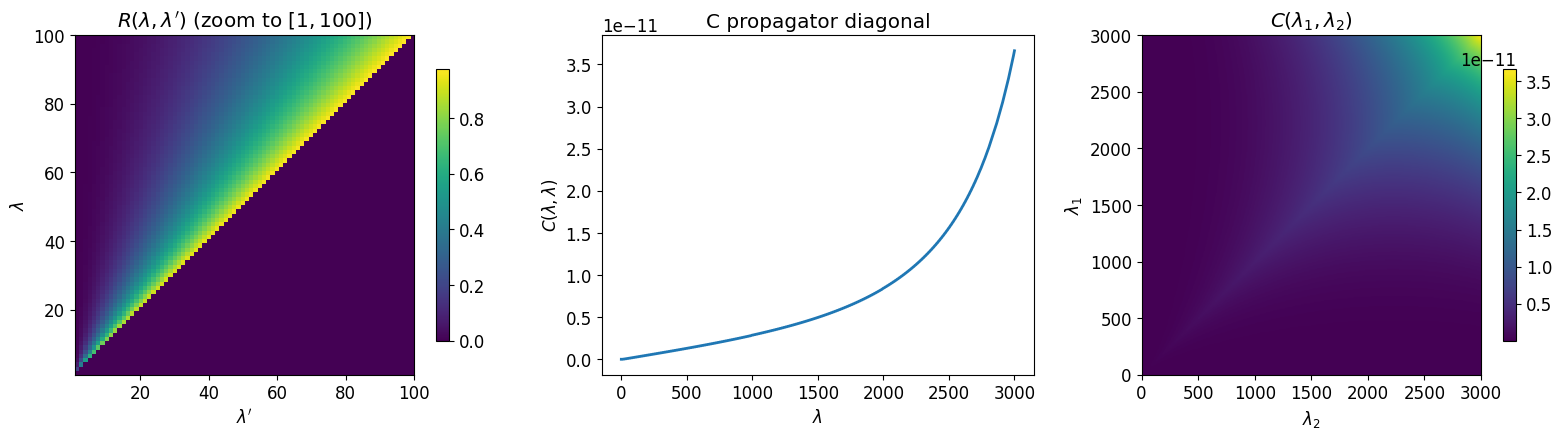

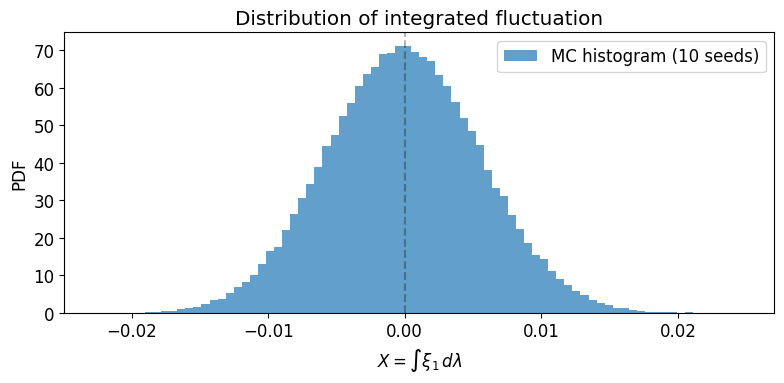

MC X: mean=-6.8662e-05, std=5.5698e-03, skew=0.0271, kurt=-0.0865


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- R(t, t') heatmap ---
N_R = 80
t_grid = np.linspace(lam_start, min(100, lam_f), N_R)  # zoom in where R is visible
Phi_grid = Phi_mc_interp(t_grid)
R_grid = np.zeros((N_R, N_R))
for i in range(N_R):
    for j in range(i):
        R_grid[i, j] = np.exp(Phi_grid[j] - Phi_grid[i])

ax = axes[0]
im = ax.imshow(R_grid, origin='lower', extent=[t_grid[0], t_grid[-1], t_grid[0], t_grid[-1]],
               aspect='equal', cmap='viridis')
ax.set_xlabel(r"$\lambda'$")
ax.set_ylabel(r"$\lambda$")
ax.set_title(r"$R(\lambda, \lambda')$ (zoom to $[1,100]$)")
plt.colorbar(im, ax=ax, shrink=0.8)

# --- C diagonal ---
ax = axes[1]
C_diag = np.diag(C_table)
ax.plot(ts, C_diag, 'C0-', lw=2)
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$C(\lambda, \lambda)$')
ax.set_title('C propagator diagonal')

# --- C heatmap ---
ax = axes[2]
im2 = ax.imshow(C_table, origin='lower', extent=[ts[0], ts[-1], ts[0], ts[-1]],
                aspect='equal', cmap='viridis')
ax.set_xlabel(r'$\lambda_2$')
ax.set_ylabel(r'$\lambda_1$')
ax.set_title(r'$C(\lambda_1, \lambda_2)$')
plt.colorbar(im2, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# --- MC histogram ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_flat, bins=80, density=True, alpha=0.7, label=f'MC histogram ({N_seeds} seeds)')
ax.set_xlabel(r'$X = \int \xi_1 \, d\lambda$')
ax.set_ylabel('PDF')
ax.set_title('Distribution of integrated fluctuation')
ax.axvline(0, color='k', ls='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f'MC X: mean={np.mean(X_flat):.4e}, std={np.std(X_flat):.4e}, '
      f'skew={np.mean((X_flat-np.mean(X_flat))**3)/np.std(X_flat)**3:.4f}, '
      f'kurt={np.mean((X_flat-np.mean(X_flat))**4)/np.std(X_flat)**4 - 3:.4f}')

## 8. Summary

In [43]:
print('='*70)
print('MOMENTS CROSS-CHECK v2 — SUMMARY')
print('='*70)
print(f'Model: C_l = A/(l(l+1)) * exp(-c*(lam1-lam2)^2)')
print(f'  A = {A:.2e}, c = {c}, sbar_1 = {sbar_1:.2e}')
print(f'  lam_f = {lam_f}, lam_start(MC) = {lam_start}, lmax = {lmax}')
print(f'  S0 = {S0:.4e}')
print(f'  Propagators tabulated on {N_out}x{N_out} grid, spline interpolation')
print(f'MC: {N_seeds} realizations x {npix} pixels, nonlinear FluctuationSolver')
print(f'sft-wick: perturbative order {perturbative_order}, QMC 2^16 samples')
print(f'  mu_0 = 1 (MSR normalization)')
print()

print('--- MC vs sft-wick tree level (order 0) ---')
print(f'{"":>6} {"tree":>14} {"MC":>14} {"MC err":>12} {"status":>8}')
print('-'*55)
for n in range(n_max + 1):
    w, m, e = moments_wick_tree[n], moments_mc[n], mc_errors[n]
    if n == 0:
        ok = 'OK'
    elif e > 0 and abs(w - m) < 3 * e:
        ok = 'OK'
    elif abs(w) < 1e-30 and abs(m) < 3 * e:
        ok = 'OK'
    else:
        ok = 'CHECK'
    print(f'mu_{n}:  {w:+14.6e} {m:+14.6e} {e:12.6e} {ok:>8}')

print()
print(f'--- MC vs sft-wick FULL (tree + 1-loop + 2-loop + 3-loop) ---')
print(f'{"":>6} {"sft-wick":>14} {"MC":>14} {"MC err":>12} {"sigma":>6} {"status":>8}')
print('-'*65)
for n in range(n_max + 1):
    w, m, e = moments_wick[n], moments_mc[n], mc_errors[n]
    sig = abs(w - m) / e if e > 0 else 0
    if n == 0:
        ok = 'OK'
    elif e > 0 and abs(w - m) < 3 * e:
        ok = 'OK'
    elif abs(w) < 1e-30 and abs(m) < 3 * e:
        ok = 'OK'
    else:
        ok = 'CHECK'
    print(f'mu_{n}:  {w:+14.6e} {m:+14.6e} {e:12.6e} {sig:6.1f} {ok:>8}')

print()
print('--- Order-by-order breakdown ---')
for n in sorted(breakdown_wick.keys()):
    parts = breakdown_wick[n]
    desc = ', '.join(f'O{o}={v:+.4e}' for o, v in sorted(parts.items()))
    print(f'  mu_{n}: {desc}')
print()
print(f'Note: MC integrates from lam_start={lam_start} (not 0), giving ~3% grid')
print(f'discretization bias. Analytic expected mu_2 for this grid: ~4.99e-06.')

MOMENTS CROSS-CHECK v2 — SUMMARY
Model: C_l = A/(l(l+1)) * exp(-c*(lam1-lam2)^2)
  A = 1.00e-15, c = 0.01, sbar_1 = -1.00e-06
  lam_f = 3000.0, lam_start(MC) = 1.0, lmax = 95
  S0 = 7.3873e-16
  Propagators tabulated on 400x400 grid, spline interpolation
MC: 10 realizations x 12288 pixels, nonlinear FluctuationSolver
sft-wick: perturbative order 3, QMC 2^16 samples
  mu_0 = 1 (MSR normalization)

--- MC vs sft-wick tree level (order 0) ---
                 tree             MC       MC err   status
-------------------------------------------------------
mu_0:   +1.000000e+00  +1.000000e+00 0.000000e+00       OK
mu_1:   +0.000000e+00  -6.866172e-05 8.084365e-07    CHECK
mu_2:   +2.944483e-05  +3.102782e-05 1.925215e-06       OK
mu_3:   +0.000000e+00  -1.704083e-09 5.610534e-09       OK
mu_4:   +2.601101e-09  +2.803599e-09 3.288840e-10       OK
mu_5:   +0.000000e+00  +5.105906e-13 1.564487e-12       OK

--- MC vs sft-wick FULL (tree + 1-loop + 2-loop + 3-loop) ---
             sft-wick   

## 9. PDF Evolution with $\lambda$

Compare the PDF of $X(\lambda) = \int_{\lambda_\mathrm{start}}^{\lambda} \xi_1(\lambda')\,d\lambda'$ at several $\lambda$ checkpoints, using:

1. **sft-wick (Gram-Charlier)**: Convert tree-level + loop moments to cumulants, build a Gram-Charlier PDF. At tree level the PDF is purely Gaussian with variance $\sigma^2(\lambda) = \int_0^\lambda \int_0^\lambda C(t_1, t_2)\,dt_1\,dt_2$.
2. **sachsfield MC (histogram)**: Pool all pixels across seeds and histogram the cumulative integral at each checkpoint.

The Gram-Charlier Type A expansion is:
$$p(x) = \frac{\varphi(z)}{\sigma}\left[1 + \frac{\gamma_1}{6}\,\mathrm{He}_3(z) + \frac{\gamma_2}{24}\,\mathrm{He}_4(z) + \cdots\right], \qquad z = \frac{x - \kappa_1}{\sigma},$$
where $\gamma_1 = \kappa_3/\sigma^3$ is the skewness, $\gamma_2 = \kappa_4/\sigma^4$ is the excess kurtosis, and $\mathrm{He}_n$ are probabilist's Hermite polynomials.

In [31]:
# --- Helper functions: cumulants and Gram-Charlier PDF ---
from math import comb
from scipy.special import factorial

def moments_to_cumulants(mu):
    """Convert raw moments [mu_0=1, mu_1, ..., mu_n] to cumulants [kappa_1, ..., kappa_n]."""
    n_max = len(mu) - 1
    kappa = np.zeros(n_max + 1)
    for n in range(1, n_max + 1):
        kappa[n] = mu[n]
        for m in range(1, n):
            kappa[n] -= comb(n - 1, m - 1) * kappa[m] * mu[n - m]
    return kappa[1:]

def hermite_he(n, z):
    """Probabilist's Hermite polynomial He_n(z) via recurrence."""
    if n == 0:
        return np.ones_like(z)
    elif n == 1:
        return z.copy()
    he_prev, he_curr = np.ones_like(z), z.copy()
    for k in range(2, n + 1):
        he_prev, he_curr = he_curr, z * he_curr - (k - 1) * he_prev
    return he_curr

def gram_charlier_pdf(x, cumulants):
    """Gram-Charlier Type A PDF from cumulants [kappa_1, kappa_2, ..., kappa_n]."""
    mean = cumulants[0]
    sigma = np.sqrt(cumulants[1])
    z = (x - mean) / sigma
    phi_z = np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)
    correction = np.ones_like(z)
    for n in range(3, len(cumulants) + 1):
        c_n = cumulants[n - 1] / sigma**n
        correction += (c_n / factorial(n, exact=True)) * hermite_he(n, z)
    return phi_z * correction / sigma

print('Gram-Charlier helpers defined.')

Gram-Charlier helpers defined.


In [32]:
# --- Full sft-wick moments at each lambda checkpoint ---
# Re-run diagram integration with different lam_f at each checkpoint.

N_ckpt = 8
lam_checkpoints = np.linspace(lam_start + 100, lam_f, N_ckpt)

# Fewer QMC samples for the evolution scan (speed vs precision tradeoff)
n_samples_scan = {0: 2**14, 1: 2**14, 2: 2**12, 3: 2**10}

# moments_wick_ckpt[ic, n] = mu_n at checkpoint ic
moments_wick_ckpt = np.zeros((N_ckpt, n_max + 1))
moments_wick_ckpt[:, 0] = 1.0  # mu_0 = 1

t0_scan = time.time()
for ic, lam_c in enumerate(lam_checkpoints):
    print(f'\n=== Checkpoint {ic}: lam = {lam_c:.1f} ===')
    for n in range(1, n_max + 1):
        reset_uid_counter()
        obs = [phi('1', f'x_{k}') for k in range(n)]
        result = compute_moment(
            obs, action, order=perturbative_order,
            response_phase=True, diag_R=True, diag_C=True, iso_R=True,
        )
        mu_n = 0.0
        for order in range(perturbative_order + 1):
            dts = result.diagram_terms(order)
            if not dts:
                continue
            ns = n_samples_scan.get(order, 2**10)
            order_total, _ = integrate_diagrams(
                dts, {'F': F_code}, lam_c, cache,
                t_min=0.0, direction=0,
                method='qmc', n_samples=ns, n_jobs=-1,
            )
            mu_n += order_total
        moments_wick_ckpt[ic, n] = mu_n
    print(f'  mu = {moments_wick_ckpt[ic]}')

print(f'\nTotal sft-wick scan: {time.time()-t0_scan:.1f}s')

# Convert to cumulants at each checkpoint
cumulants_wick_ckpt = np.zeros((N_ckpt, n_max))
for ic in range(N_ckpt):
    cumulants_wick_ckpt[ic] = moments_to_cumulants(moments_wick_ckpt[ic])

print('\nsft-wick cumulants at each checkpoint:')
for ic in range(N_ckpt):
    cum = cumulants_wick_ckpt[ic]
    print(f'  lam={lam_checkpoints[ic]:7.1f}: kappa1={cum[0]:+.4e}, kappa2={cum[1]:.4e}, kappa3={cum[2]:+.4e}')


=== Checkpoint 0: lam = 101.0 ===
  mu = [ 1.00000000e+00 -8.27857812e-10  4.69670940e-10 -1.31940233e-18
  6.61854539e-19 -3.45124966e-27]

=== Checkpoint 1: lam = 515.1 ===
  mu = [ 1.00000000e+00 -1.30591404e-07  6.11866301e-08 -2.66062558e-14
  1.12334584e-14 -8.92426876e-21]

=== Checkpoint 2: lam = 929.3 ===
  mu = [ 1.00000000e+00 -8.15912125e-07  3.73281192e-07 -1.01356318e-12
  4.18241520e-13 -2.08161144e-18]

=== Checkpoint 3: lam = 1343.4 ===
  mu = [ 1.00000000e+00 -2.67720812e-06  1.21291569e-06 -1.08187235e-11
  4.41444301e-12 -7.20295798e-17]

=== Checkpoint 4: lam = 1757.6 ===
  mu = [ 1.00000000e+00 -6.71440679e-06  3.02632107e-06 -6.79533355e-11
  2.74861489e-11 -1.13250097e-15]

=== Checkpoint 5: lam = 2171.7 ===
  mu = [ 1.00000000e+00 -1.47994556e-05  6.64663855e-06 -3.30575414e-10
  1.32560562e-10 -1.22008967e-14]

=== Checkpoint 6: lam = 2585.9 ===
  mu = [ 1.00000000e+00 -3.10065683e-05  1.38899518e-05 -1.45960912e-09
  5.78862421e-10 -1.12600742e-13]

=== Chec

In [33]:
# --- MC realizations with intermediate cumulative integrals ---
# Re-run a subset of seeds, storing X(lam) at each checkpoint.

N_seeds_pdf = 20  # fewer seeds (re-running is expensive)

# Map checkpoints to indices in lam_samples
ckpt_indices = np.searchsorted(lam_samples, lam_checkpoints)
ckpt_indices = np.clip(ckpt_indices, 0, len(lam_samples) - 1)

# Store cumulative X at each checkpoint for all seeds and pixels
# X_ckpt[ic, seed, pixel]
X_ckpt = np.zeros((N_ckpt, N_seeds_pdf, npix))

t0 = time.time()
for seed in range(N_seeds_pdf):
    source = sf.FullSkySource(
        cl_func=cl_func, lam_samples=lam_samples, nside=nside,
        corr_func=corr_func, seed=seed, n_fields=3,
    )
    source.generate()
    delta_s = source.delta_s_interpolator()

    fl = FluctuationSolver(
        theta_saddle, delta_s, source.npix,
        n_fields=3, linear_only=False,
        lam_span=(lam_start, lam_f),
        method='RK45', rtol=1e-6, atol=1e-12,
    )
    result = fl.solve(t_eval=lam_samples)
    xi1 = result.xi[:, 0, :]  # (n_lam, npix)

    # Cumulative integral at each checkpoint
    for ic, ki in enumerate(ckpt_indices):
        X_ckpt[ic, seed, :] = np.trapezoid(xi1[:ki+1], x=lam_samples[:ki+1], axis=0)

    if seed % 5 == 0:
        print(f'  seed {seed}/{N_seeds_pdf} done')

print(f'MC PDF evolution: {N_seeds_pdf} seeds in {time.time()-t0:.1f}s')
print(f'Checkpoints: {lam_checkpoints}')

  seed 0/20 done
  seed 5/20 done
  seed 10/20 done
  seed 15/20 done
MC PDF evolution: 20 seeds in 91.4s
Checkpoints: [ 101.          515.14285714  929.28571429 1343.42857143 1757.57142857
 2171.71428571 2585.85714286 3000.        ]


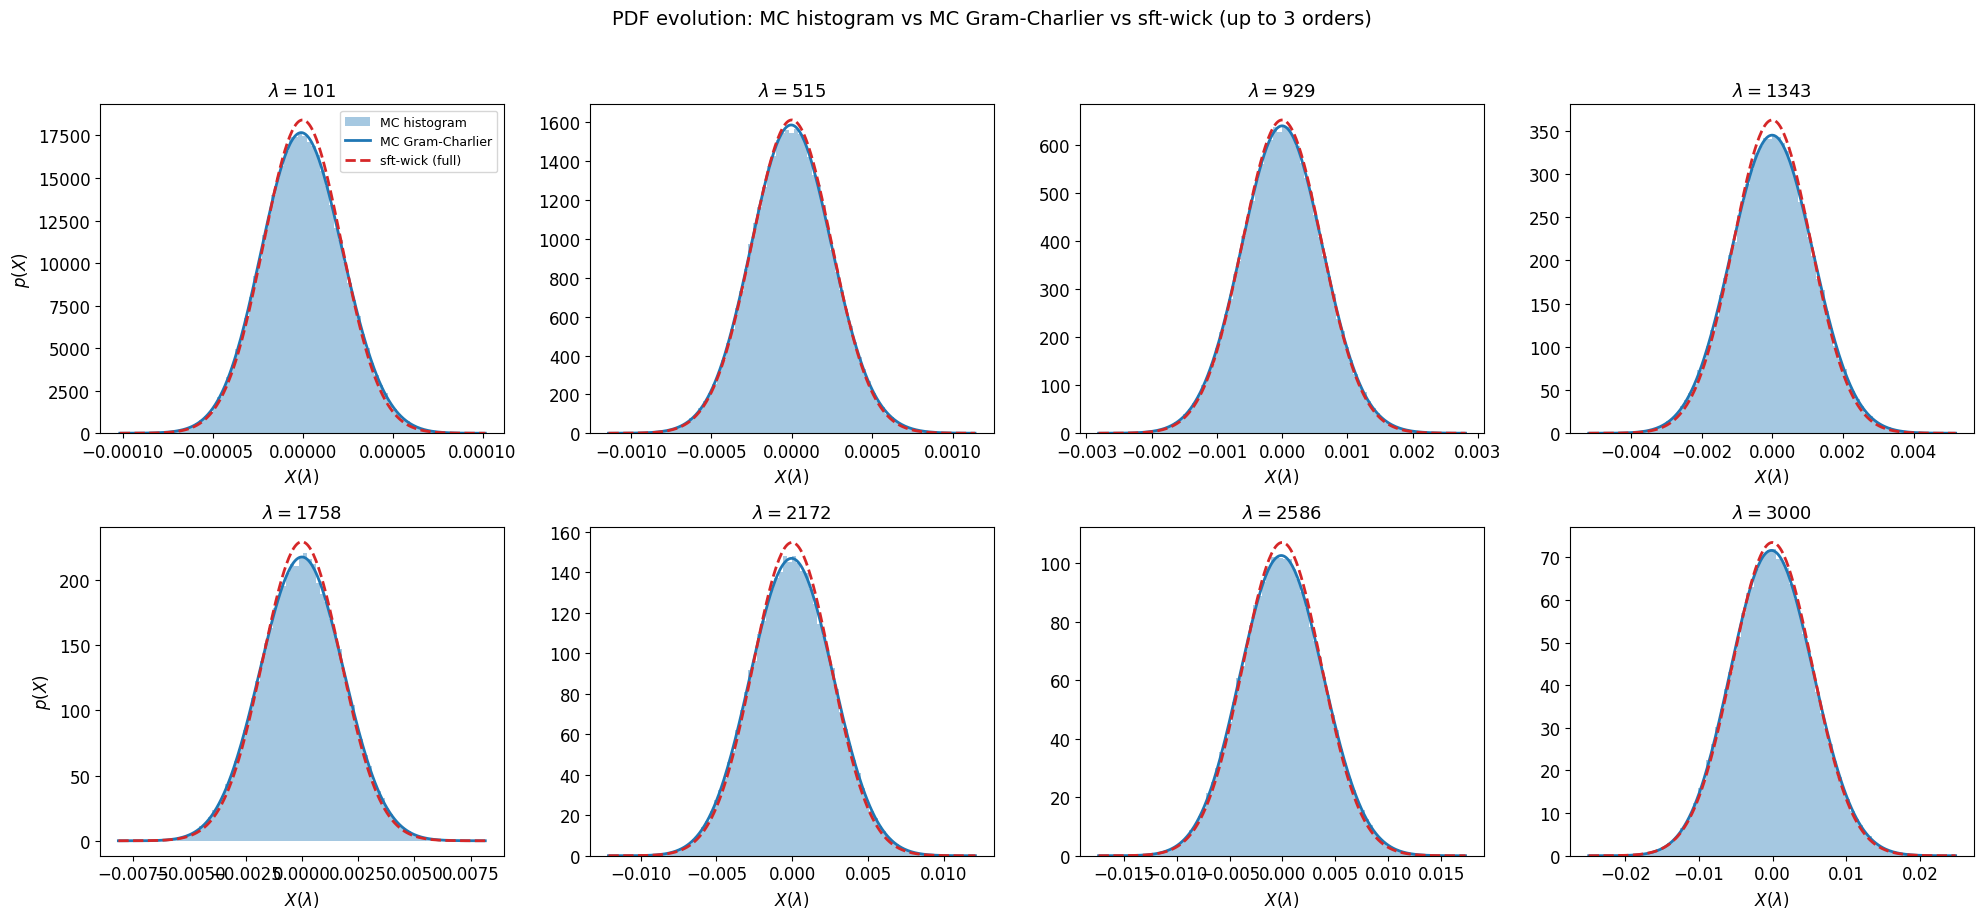


     lam |  sigma(wick) |    sigma(MC) |    ratio |  skew(wick) |   skew(MC)
------------------------------------------------------------------------
   101.0 | 2.167189e-05 | 2.256594e-05 |   1.0413 |     -0.0000 |    +0.0346
   515.1 | 2.473593e-04 | 2.528041e-04 |   1.0220 |     -0.0002 |    +0.0339
   929.3 | 6.109669e-04 | 6.250840e-04 |   1.0231 |     -0.0004 |    +0.0110
  1343.4 | 1.101321e-03 | 1.152785e-03 |   1.0467 |     -0.0008 |    +0.0125
  1757.6 | 1.739619e-03 | 1.813987e-03 |   1.0427 |     -0.0013 |    +0.0104
  2171.7 | 2.578065e-03 | 2.688193e-03 |   1.0427 |     -0.0021 |    +0.0189
  2585.9 | 3.726794e-03 | 3.854331e-03 |   1.0342 |     -0.0032 |    +0.0271
  3000.0 | 5.426671e-03 | 5.526544e-03 |   1.0184 |     -0.0051 |    +0.0322


In [34]:
# --- PDF evolution comparison plot ---

n_cols = 4
n_rows = (N_ckpt + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for ic in range(N_ckpt):
    ax = axes[ic]
    lam_c = lam_checkpoints[ic]

    # --- MC histogram ---
    X_pool = X_ckpt[ic].ravel()  # (N_seeds_pdf * npix,)
    mc_mean = np.mean(X_pool)
    mc_std = np.std(X_pool)

    ax.hist(X_pool, bins=80, density=True, alpha=0.4, color='C0',
            label='MC histogram')

    x_range = np.linspace(mc_mean - 4.5 * mc_std, mc_mean + 4.5 * mc_std, 300)

    # --- MC Gram-Charlier (from MC moments) ---
    mc_mu = np.zeros(n_max + 1)
    mc_mu[0] = 1.0
    for n in range(1, n_max + 1):
        mc_mu[n] = np.mean(X_pool**n)
    mc_cum = moments_to_cumulants(mc_mu)

    if mc_cum[1] > 0:
        pdf_mc_gc = gram_charlier_pdf(x_range, mc_cum)
        ax.plot(x_range, pdf_mc_gc, 'C0-', lw=2, label='MC Gram-Charlier')

    # --- sft-wick full Gram-Charlier PDF ---
    wick_cum = cumulants_wick_ckpt[ic]
    if wick_cum[1] > 0:
        pdf_wick = gram_charlier_pdf(x_range, wick_cum)
        ax.plot(x_range, pdf_wick, 'C3--', lw=2, label='sft-wick (full)')

    ax.set_title(rf'$\lambda = {lam_c:.0f}$', fontsize=13)
    ax.set_xlabel(r'$X(\lambda)$')
    if ic % n_cols == 0:
        ax.set_ylabel(r'$p(X)$')
    if ic == 0:
        ax.legend(fontsize=9)

# Hide unused axes
for ic in range(N_ckpt, len(axes)):
    axes[ic].set_visible(False)

fig.suptitle(r'PDF evolution: MC histogram vs MC Gram-Charlier vs sft-wick (up to 3 orders)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Print comparison at each checkpoint ---
print(f'\n{"lam":>8} | {"sigma(wick)":>12} | {"sigma(MC)":>12} | {"ratio":>8} | {"skew(wick)":>11} | {"skew(MC)":>10}')
print('-' * 72)
for ic in range(N_ckpt):
    X_pool = X_ckpt[ic].ravel()
    mc_std = np.std(X_pool)
    mc_skew = np.mean((X_pool - np.mean(X_pool))**3) / mc_std**3 if mc_std > 0 else 0
    sw = np.sqrt(cumulants_wick_ckpt[ic, 1])
    ratio = mc_std / sw if sw > 0 else np.nan
    wick_skew = cumulants_wick_ckpt[ic, 2] / sw**3 if sw > 0 else 0
    print(f'{lam_checkpoints[ic]:8.1f} | {sw:12.6e} | {mc_std:12.6e} | {ratio:8.4f} | {wick_skew:+11.4f} | {mc_skew:+10.4f}')

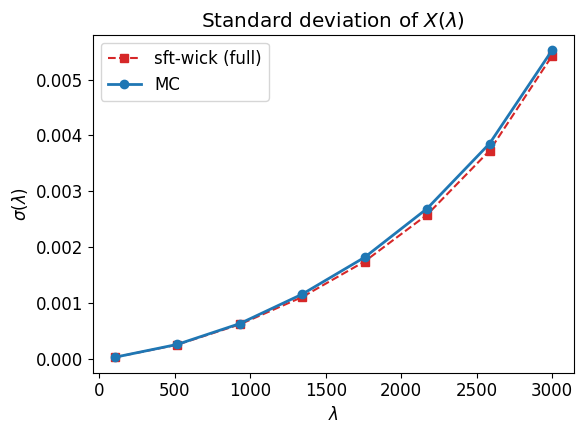

At lam_f=3000.0: sigma(wick)=5.4267e-03, sigma(MC)=5.5265e-03, ratio=1.0184


In [42]:
# --- Sigma and skewness evolution ---
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5))

sigma_mc = np.array([np.std(X_ckpt[ic].ravel()) for ic in range(N_ckpt)])
sigma_wick = np.sqrt(cumulants_wick_ckpt[:, 1])

ax1.plot(lam_checkpoints, sigma_wick, 'C3s--', lw=1.5, ms=6, label='sft-wick (full)')
ax1.plot(lam_checkpoints, sigma_mc, 'C0o-', lw=2, ms=6, label='MC')
ax1.set_xlabel(r'$\lambda$')
ax1.set_ylabel(r'$\sigma(\lambda)$')
ax1.set_title(r'Standard deviation of $X(\lambda)$')
ax1.legend()

# skew_mc = np.array([
#     np.mean((X_ckpt[ic].ravel() - np.mean(X_ckpt[ic].ravel()))**3) / np.std(X_ckpt[ic].ravel())**3
#     if np.std(X_ckpt[ic].ravel()) > 0 else 0
#     for ic in range(N_ckpt)
# ])
# skew_wick = np.array([
#     cumulants_wick_ckpt[ic, 2] / np.sqrt(cumulants_wick_ckpt[ic, 1])**3
#     if cumulants_wick_ckpt[ic, 1] > 0 else 0
#     for ic in range(N_ckpt)
# ])

plt.tight_layout()
plt.show()

print(f'At lam_f={lam_f}: sigma(wick)={sigma_wick[-1]:.4e}, sigma(MC)={sigma_mc[-1]:.4e}, '
      f'ratio={sigma_mc[-1]/sigma_wick[-1]:.4f}')
